# Examples using the helper functions of rNDC

Higher-level functions that retrieve ready-to-use data for an area of interest: study sites, land use and nitrogen rasters (*NatureDataCube*), weather data (*AgroDataCube*) and monthly NDVI (*GroenMonitor*).

**Author:** Bruno Marcos

**Created in:** October 2, 2026

## Settings

In [1]:
# Load packages
pkgs <- c("sf", "terra", "rNDC")
suppressPackageStartupMessages(
  invisible(lapply(pkgs, FUN = library, character.only = TRUE))
)

# Tokens are read from environment variables by default (`NDC_TOKEN`);
# the AgroDataCube token is passed explicitly (`ADC_TOKEN`)
adc_token <- Sys.getenv("ADC_TOKEN")

## 1. Study sites

`ndc_sites()` lists the study sites bundled with the package, and returns the boundaries of one of them when a name is given.

In [2]:
ndc_sites()

[1] "nutnet_poly"                           
[2] "nestkasten_vlieland_poly"              
[3] "nestkasten_veluwe_poly"                
[4] "nestkasten_liesbosch_poly"             
[5] "nestkasten_boslust_poly"               
[6] "nestkasten_bennekom_poly"              
[7] "loobos"                                
[8] "20251008_licht_op_natuur_lantaarnpalen"


Simple feature collection with 1 feature and 0 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.706219 ymin: 52.14783 xmax: 5.785891 ymax: 52.18321
Geodetic CRS:  WGS 84
                            geom
1 MULTIPOLYGON (((5.706219 52...


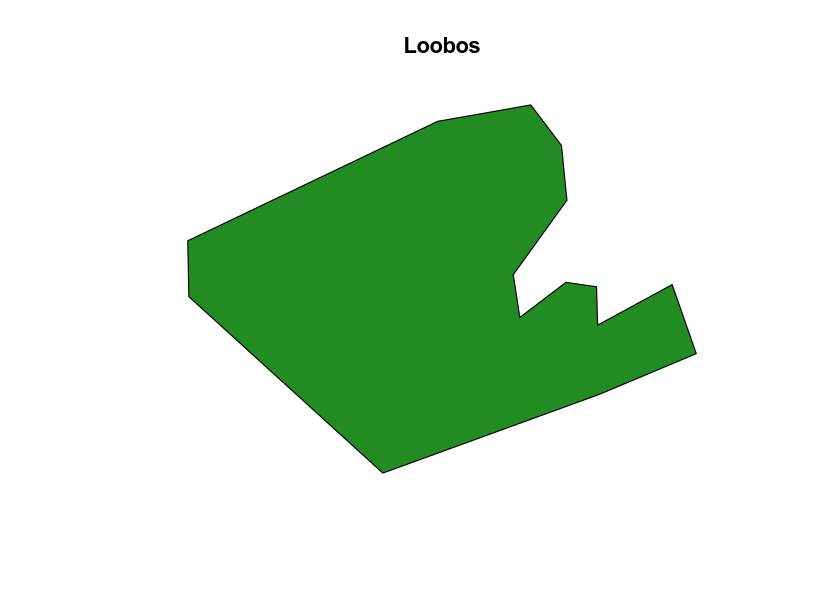

In [3]:
site <- ndc_sites("loobos")
print(site)
plot(st_geometry(site), col = "forestgreen", main = "Loobos")

## 2. Land use

`get_landuse_raster()` downloads the LGN land use raster for an area of interest (clipped to the area) and returns a list with the raster (`stack`), the downloaded `files` and the item `metadata`.

In [4]:
landuse <- get_landuse_raster(site, year = 2024)
print(landuse$stack)
landuse$metadata[, c("id", "title", "observation_date")]

class       : SpatRaster 
dimensions  : 798, 1099, 1  (nrow, ncol, nlyr)
resolution  : 5, 5  (x, y)
extent      : 685060, 690555, 5781015, 5785005  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source(s)   : memory
varname     : LGN_2024 
name        : LGN_2024 
min value   :        1 
max value   :      333 
# A tibble: 1 × 3
  id              title                  observation_date
  <chr>           <chr>                  <chr>           
1 ndc-lgn2024_05m LGN Land Use 2024 (5m) 2024-01-01      


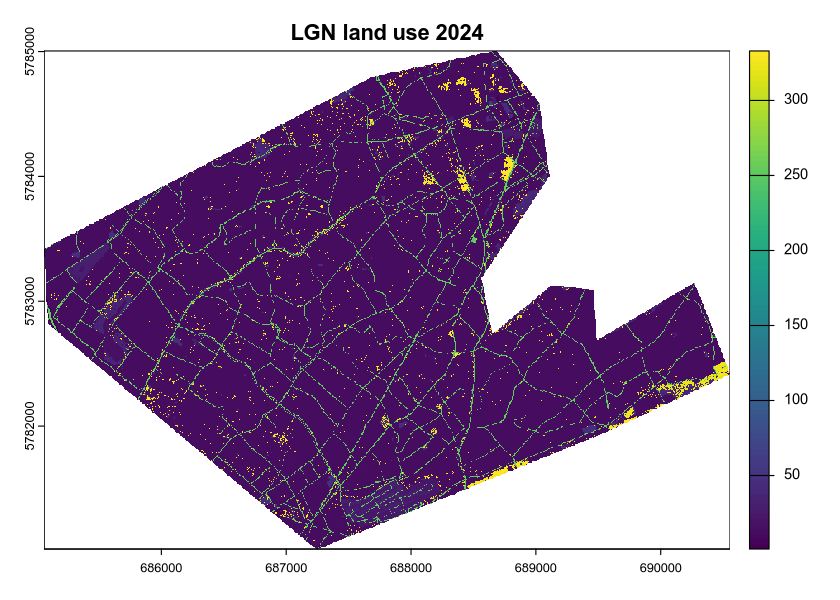

In [5]:
plot(landuse$stack, main = "LGN land use 2024")

## 3. Nitrogen

`get_nitrogen_raster()` downloads the total nitrogen deposition (`ntot`), nitrogen oxides concentration (`nox`) and ammonia concentration (`nh3`) rasters for a given year (2024, 2025 or 2040), clipped to the area of interest.

In [6]:
nitrogen <- get_nitrogen_raster(site, year = 2025)
print(nitrogen$stack)
nitrogen$metadata[, c("layer", "year", "title")]

class       : SpatRaster 
dimensions  : 4, 5, 3  (nrow, ncol, nlyr)
resolution  : 1000, 1000  (x, y)
extent      : 685000, 690000, 5781000, 5785000  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source(s)   : memory
varnames    : ntot_2025 
              nox_2025 
              nh3_2025 
names       : ntot_2025, nox_2025, nh3_2025 
min values  :      1253,    8.183,    4.033 
max values  :      2140,   11.040,    9.931 
# A tibble: 3 × 3
  layer year  title                                   
  <chr> <chr> <chr>                                   
1 ntot  2025  Total Nitrogen Deposition (NTOT) 2025   
2 nox   2025  Nitrogen Oxides Concentration (NOx) 2025
3 nh3   2025  Ammonia Concentration (NH3) 2025        


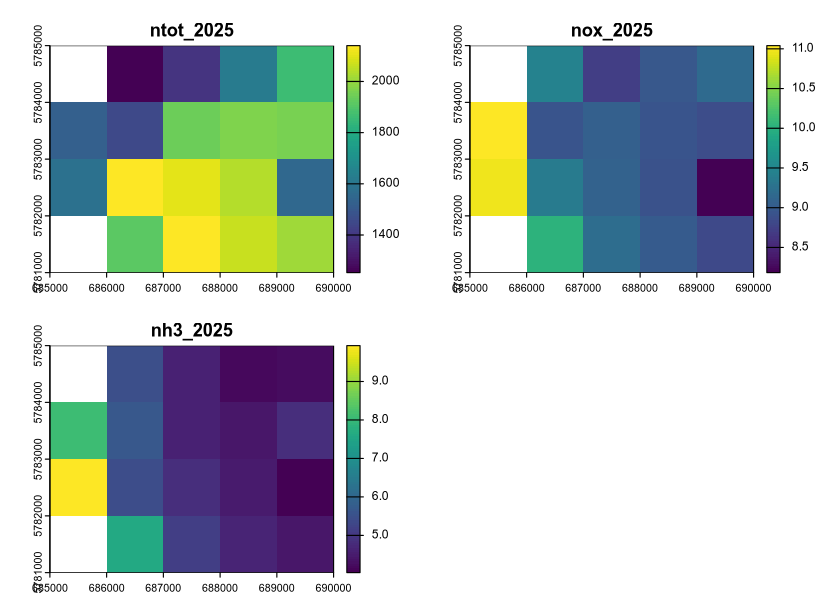

In [7]:
plot(nitrogen$stack)

In [8]:
nitrogen_2040 <- get_nitrogen_raster(site, year = 2040, layers = "ntot")
global(c(nitrogen$stack[["ntot_2025"]], nitrogen_2040$stack), "mean", na.rm = TRUE)

              mean
ntot_2025 1804.833
ntot_2040 1300.539


## 4. Weather data (*AgroDataCube*)

### 4.1. Closest meteorological station

`get_closest_meteostation()` takes the study area as a WKT string (EPSG:4326).

In [9]:
site_wkt <- st_as_text(st_union(st_geometry(st_transform(site, 4326))))
station <- get_closest_meteostation(site_wkt, token = adc_token)
station$closest_id
round(min(station$distances) / 1000, 1) # distance in km

[1] "275"
[1] 15


### 4.2. One day

In [10]:
day <- get_meteo_for_date(station$closest_id, "2025-07-15", token = adc_token)
st_drop_geometry(day)[, c("datum", "mean_temperature", "min_temperature", "max_temperature", "precipitation")]

       datum mean_temperature min_temperature max_temperature precipitation
1 2025-07-15             18.5            14.6            23.3           9.1


### 4.3. A period

One request is made (up to `page_size` rows).

In [11]:
week <- get_meteo_for_period(station$closest_id, "2025-07-01", "2025-07-07", token = adc_token)
st_drop_geometry(week)[, c("datum", "mean_temperature", "precipitation")]

       datum mean_temperature precipitation
1 2025-07-01             28.4           0.0
2 2025-07-02             24.7           2.1
3 2025-07-03             17.4           0.0
4 2025-07-04             18.1           0.0
5 2025-07-05             18.6           0.3
6 2025-07-06             17.2          12.8
7 2025-07-07             15.7           2.3


### 4.4. A long period

`get_meteo_for_long_period()` splits the period in chunks of `by_days` days and combines the results.

[1] 92


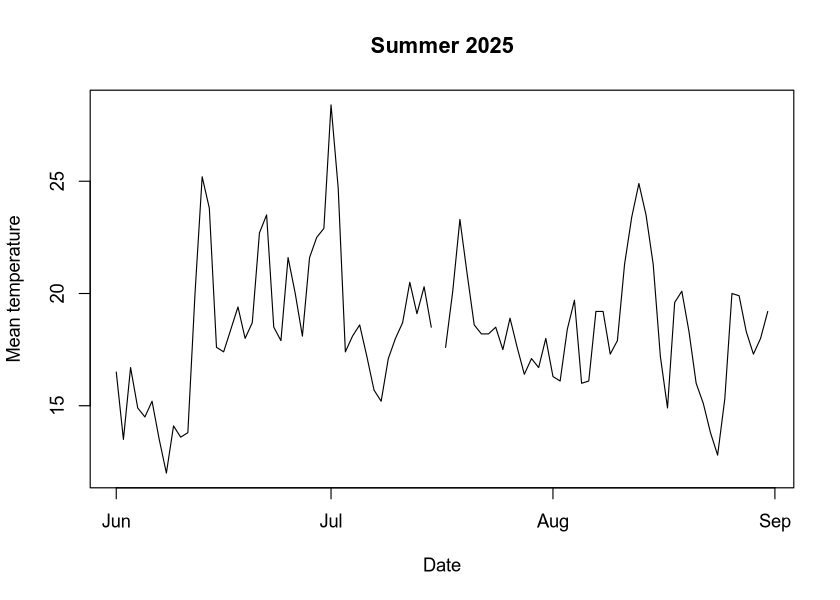

In [12]:
summer <- suppressMessages(
  get_meteo_for_long_period(station$closest_id, "2025-06-01", "2025-08-31", token = adc_token, by_days = 30)
)
nrow(summer)
plot(as.Date(summer$datum), summer$mean_temperature, type = "l",
     xlab = "Date", ylab = "Mean temperature", main = "Summer 2025")

## 5. Monthly NDVI (*GroenMonitor*)

`download_avg_ndvi_month()` downloads the daily NDVI rasters of a month for the area of interest and averages them. Days without data are skipped; `download_avg_ndvi_stack()` does the same for a range of months.

In [13]:
ndvi <- download_avg_ndvi_month(site, year = 2025, month = 7)
print(ndvi)

Processing July 2025 (2025-07-01 to 2025-07-31)
Skipping 20250701 (not available)
Downloaded 20250702
Skipping 20250703 (not available)
Skipping 20250704 (not available)
Skipping 20250705 (not available)
Skipping 20250706 (not available)
Skipping 20250707 (not available)
Skipping 20250708 (not available)
Skipping 20250709 (not available)
Downloaded 20250710
Skipping 20250711 (not available)
Skipping 20250712 (not available)
Skipping 20250713 (not available)
Skipping 20250714 (not available)
Downloaded 20250715
Skipping 20250716 (not available)
Skipping 20250717 (not available)
Skipping 20250718 (not available)
Skipping 20250719 (not available)
Skipping 20250720 (not available)
Skipping 20250721 (not available)
Skipping 20250722 (not available)
Skipping 20250723 (not available)
Skipping 20250724 (not available)
Skipping 20250725 (not available)
Skipping 20250726 (not available)
Skipping 20250727 (not available)
Skipping 20250728 (not available)
Skipping 20250729 (not available)
Skipping

class       : SpatRaster 
dimensions  : 399, 549, 1  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 685060, 690550, 5781020, 5785010  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source(s)   : memory
name        : ndvi_mean_202507 
min value   :                1 
max value   :              233 


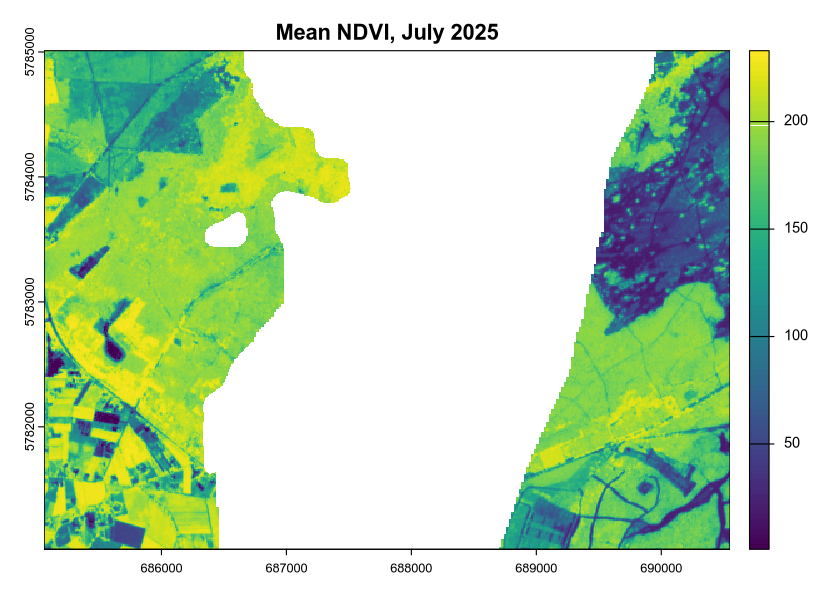

In [14]:
plot(ndvi, main = "Mean NDVI, July 2025")